In [1]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt

/home/adriano/projects/alphag_frequentist_analysis_2025/Bfield_multifidelity/myvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# train data is 100 points
xmax = 1
train_x = torch.linspace(0,xmax,200)
# True function
train_y = torch.exp(-train_x/(0.5*math.pi)) * torch.sin(train_x * (10 * math.pi) + math.pi/2) + torch.randn(train_x.size()) * math.sqrt(0.04)
#train_y = torch.sin(train_x * (10 * math.pi) + math.pi/2) + torch.randn(train_x.size()) * math.sqrt(0.04)

In [3]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        #self.covar_module = gpytorch.kernels.ScaleKernel( gpytorch.kernels.PeriodicKernel() * gpytorch.kernels.RBFKernel())
        self.covar_module = gpytorch.kernels.ScaleKernel( gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)
model.covar_module.base_kernel.lengthscale = 0.1

In [4]:
training_iter = 500

# Find optimal model hyperparameters
model.train(); likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)   # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -mll(output, train_y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
       i + 1, training_iter, loss.item(),
       model.covar_module.base_kernel.lengthscale.item(),
       model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/500 - Loss: 0.956   lengthscale: 0.100   noise: 0.693
Iter 2/500 - Loss: 0.951   lengthscale: 0.099   noise: 0.688
Iter 3/500 - Loss: 0.946   lengthscale: 0.098   noise: 0.683
Iter 4/500 - Loss: 0.940   lengthscale: 0.097   noise: 0.678
Iter 5/500 - Loss: 0.935   lengthscale: 0.096   noise: 0.673
Iter 6/500 - Loss: 0.929   lengthscale: 0.095   noise: 0.669
Iter 7/500 - Loss: 0.924   lengthscale: 0.094   noise: 0.664
Iter 8/500 - Loss: 0.918   lengthscale: 0.094   noise: 0.659
Iter 9/500 - Loss: 0.912   lengthscale: 0.093   noise: 0.654
Iter 10/500 - Loss: 0.906   lengthscale: 0.092   noise: 0.649
Iter 11/500 - Loss: 0.901   lengthscale: 0.091   noise: 0.644
Iter 12/500 - Loss: 0.895   lengthscale: 0.090   noise: 0.640
Iter 13/500 - Loss: 0.889   lengthscale: 0.089   noise: 0.635
Iter 14/500 - Loss: 0.884   lengthscale: 0.088   noise: 0.630
Iter 15/500 - Loss: 0.878   lengthscale: 0.087   noise: 0.625
Iter 16/500 - Loss: 0.872   lengthscale: 0.087   noise: 0.621
Iter 17/500 - Los

In [5]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_x = torch.linspace(0, xmax, 200)
    observed_pred = likelihood(model(test_x))

/home/adriano/projects/alphag_frequentist_analysis_2025/Bfield_multifidelity/myvenv/lib/python3.10/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


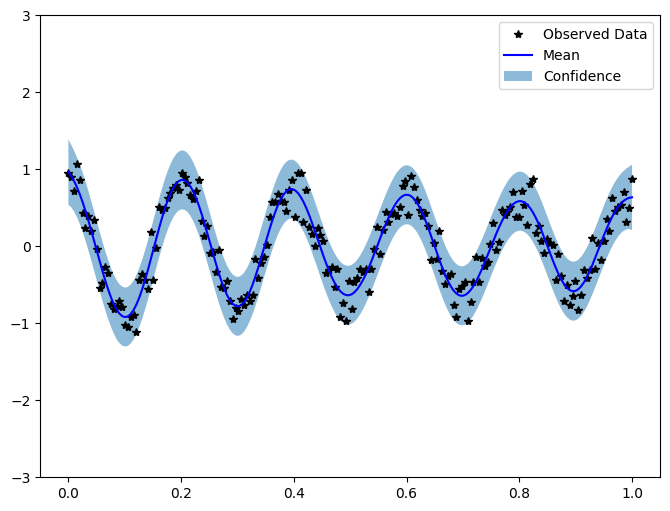

In [6]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(4*2, 3*2))

    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax.plot(train_x.numpy(), train_y.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(test_x.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    ax.set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])